In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Libraries imported!")

Libraries imported!


In [3]:
df = pd.read_csv('scraped_books.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000, 3)


,Title,Price,Rating
0,A Light in the Attic,£51.77,Three
1,Tipping the Velvet,£53.74,One
2,Soumission,£50.10,One
3,Sharp Objects,£47.82,Four
4,Sapiens: A Brief History of Humankind,£54.23,Five


In [4]:
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   1000 non-null   object
 1   Price   1000 non-null   object
 2   Rating  1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB
None

Basic Statistics:


,Title,Price,Rating
count,1000,1000,1000
unique,999,903,5
top,The Star-Touched Queen,£44.18,One
freq,2,3,226


In [6]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Title     0
Price     0
Rating    0
dtype: int64

Duplicate Rows: 0


In [11]:
print("Average Price: £", round(df['Price'].mean(), 2))
print("Highest Price: £", df['Price'].max())
print("Lowest Price: £", df['Price'].min())
print("Median Price: £", df['Price'].median())

Average Price: £ 35.07
Highest Price: £ 59.99
Lowest Price: £ 10.0
Median Price: £ 35.980000000000004


In [12]:
print("Rating Distribution:")
print(df['Rating'].value_counts().sort_index())
print("\nAverage Rating:", round(df['Rating'].mean(), 2))

Rating Distribution:
Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

Average Rating: 2.92


In [13]:
avg_price_by_rating = df.groupby('Rating')['Price'].mean().round(2)
print("Average Price by Rating:")
print(avg_price_by_rating)

Average Price by Rating:
Rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37
Name: Price, dtype: float64


In [14]:
correlation = df['Price'].corr(df['Rating'])
print("Correlation between Price and Rating:", round(correlation, 2))

Correlation between Price and Rating: 0.03


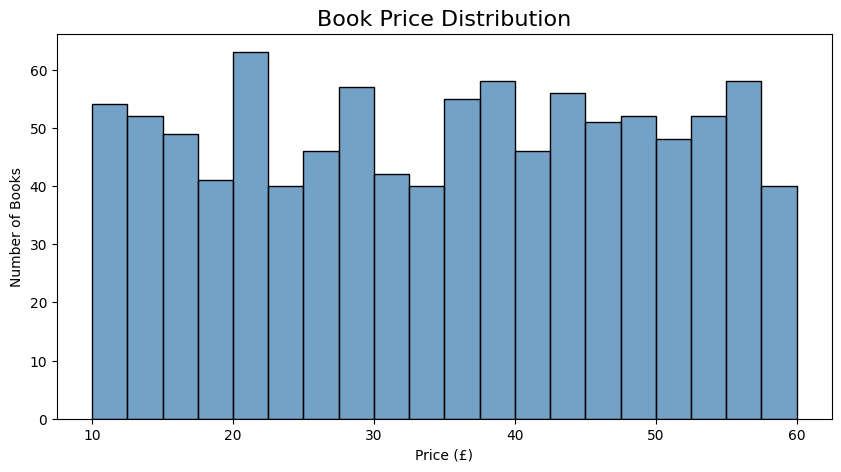

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=20, color='steelblue')
plt.title('Book Price Distribution', fontsize=16)
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.savefig('price_distribution.png')
plt.show()

/tmp/ipykernel_1626/2898172301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis')


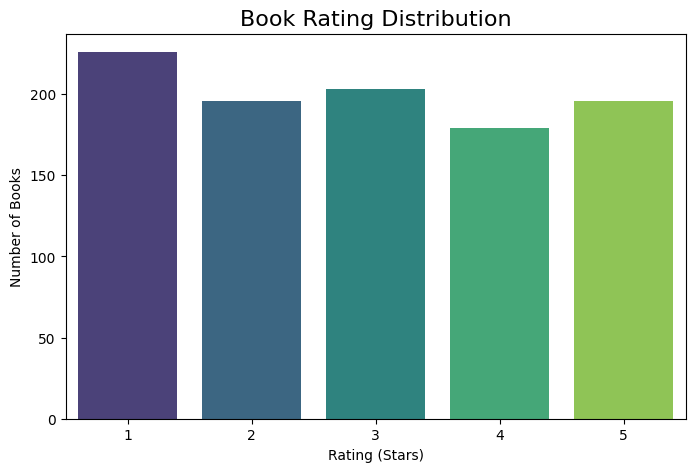

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Rating', palette='viridis')
plt.title('Book Rating Distribution', fontsize=16)
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Books')
plt.savefig('rating_distribution.png')
plt.show()

/tmp/ipykernel_1626/2406740351.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Rating', y='Price', palette='coolwarm')


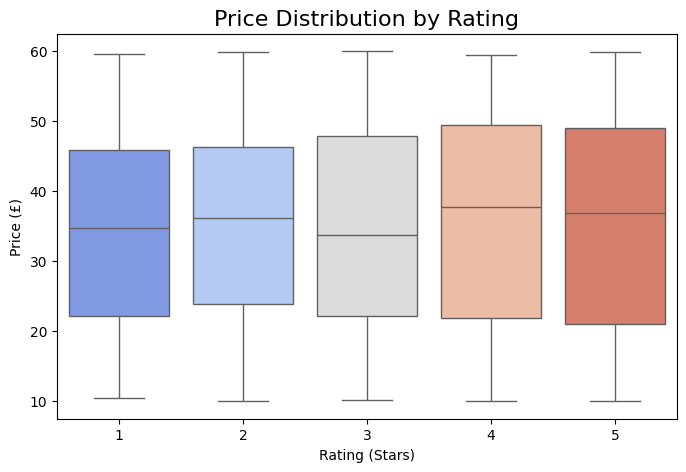

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Rating', y='Price', palette='coolwarm')
plt.title('Price Distribution by Rating', fontsize=16)
plt.xlabel('Rating (Stars)')
plt.ylabel('Price (£)')
plt.savefig('price_by_rating.png')
plt.show()

In [18]:
top10 = df.nlargest(10, 'Price')[['Title', 'Price', 'Rating']]
print("Top 10 Most Expensive Books:")
print(top10)

Top 10 Most Expensive Books:
                                                 Title  Price  Rating
648                 The Perfect Play (Play by Play #1)  59.99       3
617                  Last One Home (New Beginnings #1)  59.98       3
860                   Civilization and Its Discontents  59.95       2
560                     The Barefoot Contessa Cookbook  59.92       5
366                          The Diary of a Young Girl  59.90       3
657  The Bone Hunters (Lexy Vaughan & Steven Macaul...  59.71       3
133  Thomas Jefferson and the Tripoli Pirates: The ...  59.64       1
387                      Boar Island (Anna Pigeon #19)  59.48       3
393                          The Improbability of Love  59.45       1
549  The Man Who Mistook His Wife for a Hat and Oth...  59.45       4


In [19]:
top_rated = df[df['Rating']==5].nlargest(10, 'Price')[['Title','Price','Rating']]
print("Top 10 Five Star Books:")
print(top_rated)

Top 10 Five Star Books:
                                                 Title  Price  Rating
560                     The Barefoot Contessa Cookbook  59.92       5
812                              Life Without a Recipe  59.04       5
637     Approval Junkie: Adventures in Caring Too Much  58.81       5
379  How to Speak Golf: An Illustrated Guide to Lin...  58.32       5
631                                   Digital Fortress  58.00       5
545                                  The Sound Of Love  57.84       5
910         Travels with Charley: In Search of America  57.82       5
309                                           El Deafo  57.62       5
898                                      H is for Hawk  57.42       5
100  Immunity: How Elie Metchnikoff Changed the Cou...  57.36       5
